<a href="https://colab.research.google.com/github/Aryan-yadav7/ML_learning/blob/main/normalised_multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("FAOSTAT_data_en_8-18-2026.csv")

print(df.head())
print(df.shape)

  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              392  Japan   
1         QCL  Crops and livestock products              392  Japan   
2         QCL  Crops and livestock products              392  Japan   
3         QCL  Crops and livestock products              392  Japan   
4         QCL  Crops and livestock products              392  Japan   

   Element Code         Element  Item Code (CPC)  Item  Year Code  Year  \
0          5312  Area harvested              113  Rice       1961  1961   
1          5412           Yield              113  Rice       1961  1961   
2          5510      Production              113  Rice       1961  1961   
3          5312  Area harvested              113  Rice       1962  1962   
4          5412           Yield              113  Rice       1962  1962   

    Unit       Value Flag Flag Description  Note  
0     ha   3312000.0    A   Official value   NaN  
1  kg/ha      4879.4

In [ ]:
print(df.columns)

print(df["Element"].value_counts())

print(df[["Year", "Element", "Value", "Unit"]].head(10))

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')
Element
Area harvested    64
Yield             64
Production        64
Name: count, dtype: int64
   Year         Element       Value   Unit
0  1961  Area harvested   3312000.0     ha
1  1961           Yield      4879.4  kg/ha
2  1961      Production  16160440.0      t
3  1962  Area harvested   3295000.0     ha
4  1962           Yield      5137.2  kg/ha
5  1962      Production  16927100.0      t
6  1963  Area harvested   3276000.0     ha
7  1963           Yield      5082.1  kg/ha
8  1963      Production  16648830.0      t
9  1964  Area harvested   3264000.0     ha


In [ ]:
df_wide = df.pivot(
    index="Year",
    columns="Element",
    values="Value"
).reset_index()

print(df_wide.head())

Element  Year  Area harvested  Production   Yield
0        1961       3312000.0  16160440.0  4879.4
1        1962       3295000.0  16927100.0  5137.2
2        1963       3276000.0  16648830.0  5082.1
3        1964       3264000.0  16356100.0  5011.1
4        1965       3258500.0  16126060.0  4948.9


In [ ]:
print(df_wide.isnull().sum())

Element
Year              0
Area harvested    0
Production        0
Yield             0
dtype: int64


In [ ]:
X = df_wide[["Year", "Area harvested", "Yield"]]

y = df_wide["Production"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (51, 3)
Testing data: (13, 3)


In [ ]:
means = X_train.mean()

print(means)

Element
Year              1.992412e+03
Area harvested    2.169586e+06
Yield             6.143876e+03
dtype: float64


In [ ]:
stds = X_train.std()

print(stds)

Element
Year                  17.963492
Area harvested    580693.830523
Yield                618.379036
dtype: float64


In [ ]:
X_train_normalized = (X_train - means) / stds

print(X_train_normalized.head())

Element      Year  Area harvested     Yield
13      -1.024955        0.954744 -0.458257
34       0.144083       -0.088836  0.322332
50       1.034778       -0.961929  0.812323
3       -1.581639        1.884666 -1.831848
17      -0.802281        0.651658  0.051625


In [ ]:
X_test_normalized = (X_test - means) / stds

print(X_test_normalized.head())

Element      Year  Area harvested     Yield
52       1.146115       -0.944708  1.273691
58       1.480126       -1.080408  1.116829
0       -1.748645        1.967325 -2.044824
44       0.700768       -0.798332  0.815719
5       -1.470302        1.874333 -1.713798


In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_normalized, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_normalized)

print(y_pred)

[11394008.78074738 10523484.51937422 16884390.34753451 11487580.04174842
 16887059.43313239 12467383.86378076 16580722.12655988 15767016.97135696
 14392766.71839119 10518057.72797815 10888551.00909125 16441123.74435929
 11636857.32442418]


In [ ]:
errors = y_test - y_pred

squared_errors = errors**2

sum = 0
for i in squared_errors:
  sum = sum + i

n = X_test.shape[0]

mse = sum/n
print(mse)

77507722329.65996


In [ ]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 278402.08750952274


In [ ]:
errors = y_test - y_pred

absolute_errors = abs(errors)

total = 0
for i in absolute_errors:
  total = total + i

n = X_test.shape[0]

mae = total/n

print("MAE: ", mae)

MAE:  198512.82467953674


In [ ]:
errors = y_test - y_pred

# Sum of squared errors
ss_res = 0
for i in errors:
    ss_res += i ** 2

# Mean of actual test values
mean_y = y_test.mean()

# Total sum of squares
ss_tot = 0
for i in y_test:
    ss_tot += (i - mean_y) ** 2

r2 = 1 - (ss_res / ss_tot)

print("R²:", r2)

R²: 0.9881361972332149


In [ ]:
print("R²:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R²: 0.9881361972332149
MAE: 198512.82467953674
MSE: 77507722329.65996
RMSE: 278402.08750952274


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

          Feature   Coefficient
0            Year -8.069258e+05
1  Area harvested  2.744170e+06
2           Yield  1.457457e+06


In [ ]:
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

Intercept: 13054930.588235293
Year : -798975.596673865
Area harvested : 2717133.5191237573
Yield : 1443097.114369027


In [ ]:
results = pd.DataFrame({
    "Actual Production": y_test.values,
    "Predicted Production": y_pred,
    "Difference" : y_test.values - y_pred
})

print(results)

    Actual Production  Predicted Production     Difference
0          11236000.0          1.139401e+07 -158008.780747
1          10540100.0          1.052348e+07   16615.480626
2          16160440.0          1.688439e+07 -723950.347535
3          11342000.0          1.148758e+07 -145580.041748
4          16564000.0          1.688706e+07 -323059.433132
5          12531000.0          1.246738e+07   63616.136219
6          17006000.0          1.658072e+07  425277.873440
7          15778000.0          1.576702e+07   10983.028643
8          14559000.0          1.439277e+07  166233.281609
9          10451000.0          1.051806e+07  -67057.727978
10         10777000.0          1.088855e+07 -111551.009091
11         16493000.0          1.644112e+07   51876.255641
12         11320000.0          1.163686e+07 -316857.324424


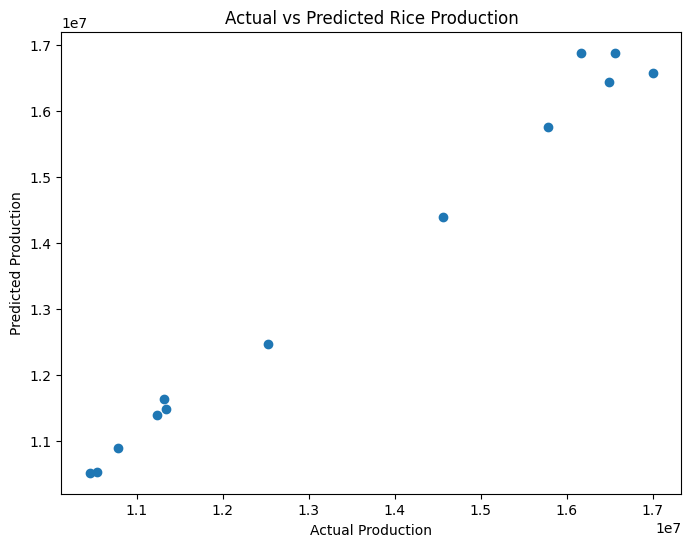

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Rice Production")

plt.show()